# Implement trained model using HLS4ML
Having downloaded the dataset, defined the CNN model and trained with pertinent data, it's time to synthesize it using HLS4ML.

In [22]:
import os, json, re, warnings
import tensorflow as tf
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ['XILINX_VITIS'] = '/tools/Xilinx/Vitis/2024.1'
os.environ['XILINX_HLS'] = '/tools/Xilinx/Vitis_HLS/2024.1'
os.environ['PATH'] += ':/tools/Xilinx/Vitis_HLS/2024.1/bin'
os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']


# QKeras – quantization-aware training
from qkeras import QConv2D, QDense, QActivation, quantized_bits, quantized_relu
from qkeras.utils import _add_supported_quantized_objects

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import (InputLayer, 
                                     BatchNormalization,
                                     MaxPooling2D,
                                     Flatten,
                                     Dropout                                
)
from tensorflow.keras.optimizers import Adam

co = {}
_add_supported_quantized_objects(co)
model_MFCC = load_model('CNN_Model_Trained/Trained_model_100e.h5', custom_objects=co)
# hls4ml – HLS model conversion and synthesis
import hls4ml

## Reproducibility
RANDOM_SEED = 55
#np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
warnings.filterwarnings('ignore')


# ── FPGA target (Kria KV260-compatible) ───────────────────────────────────
FPGA_PART    = 'xck26-sfvc784-2LV-c'
CLOCK_PERIOD = 5   # ns → 200 MHz
TARGET_SNR   = '76dB'

# ── hls4ml output ─────────────────────────────────────────────────────────
HLS_BASE_DIR = './hls4ml_output'

# ── Training hyper-parameters ─────────────────────────────────────────────
BATCH_SIZE    = 32
MAX_EPOCHS    = 150
LEARNING_RATE = 1e-3
PATIENCE      = 20



# Load dataset parameters for QAT

In [2]:
# ── Datasets parameters ─────────────────────────────────────────────
DATASETS_PATH = "MFCC_datasets"
METADATA_PATH = os.path.join(DATASETS_PATH, "metadata.json")

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, "r") as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata["MFCC_input_shape"])
    NUM_CLASSES      = metadata["num_classes"]
    N_MFCC           = metadata.get("N_MFCC", 20)
    MFCC_FRAMES      = metadata.get("MFCC_FRAMES")
    SAMPLING_FREQ    = metadata.get("SAMPLING_FREQ", 48000)
    batch_size       = metadata.get("batch_size", 32)
    subfolders       = metadata.get("subfolders", [])
    unique_labels    = metadata.get("labels", [])
    print("Metadata loaded from metadata.json")
else:
    # Fallback: infer parameters from the dataset after loading
    print("Warning: metadata.json not found. Parameters will be inferred from the dataset.")
    N_MFCC        = 20
    SAMPLING_FREQ = 48000
    batch_size    = 32
    subfolders    = []
    MFCC_input_shape = None
    NUM_CLASSES      = None

print(f"  MFCC input shape : {MFCC_input_shape}")
print(f"  Num classes      : {NUM_CLASSES}")
print(f"  N_MFCC           : {N_MFCC}")
print(f"  MFCC_FRAMES      : {MFCC_FRAMES}")
print(f"  Sampling freq    : {SAMPLING_FREQ} Hz")
print(f"  Batch size       : {batch_size}")
print(f"  Classes          : {subfolders}")


Metadata loaded from metadata.json
  MFCC input shape : (20, 282, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 282
  Sampling freq    : 48000 Hz
  Batch size       : 32
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']


# Quantization-Aware Training (QAT)

Three QKeras models are fine-tuned starting from the float weights:

| Model | Weight / activation precision |
|---|---|
| QAT 16-bit | `quantized_bits(16, 6)` |
| QAT 8-bit  | `quantized_bits(8, 4)`  |
| QAT 4-bit  | `quantized_bits(4, 2)`  |

Fine-tuning starts from the float checkpoint; fewer epochs and a lower
learning rate let the network adapt to reduced precision without
catastrophic forgetting.

In [3]:

def build_qat_model(input_shape, n_classes, bits, integer_bits):

    #Quantizers
    kq = quantized_bits(bits, integer_bits, keep_negative=1, alpha=1)
    aq = quantized_relu(bits, integer_bits)

    q_Model = Sequential([
        InputLayer(input_shape),

        #Block 1
        QConv2D(8, (3,3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv1'),
        BatchNormalization(name='bn1',trainable=True),
        QActivation(activation=aq, name='act1'),
        MaxPooling2D((2,2), name='pool1'),

        #Block 2
        QConv2D(8, (3,3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv2'),
        BatchNormalization(name='bn2',trainable=True),
        QActivation(activation=aq, name='act2'),
        MaxPooling2D((2,4), name='pool2'),

        #Block 3
        QConv2D(8, (3,3), padding='same',
                kernel_quantizer=kq, bias_quantizer=kq, name='conv3'),
        BatchNormalization(name='bn3',trainable=True),
        QActivation(activation=aq, name='act3'),
        MaxPooling2D((5,4), name='pool3'),

        #Classifier
        Flatten(name='flatten'),
        QDense(16, kernel_quantizer=kq, bias_quantizer=kq, name='dense1'),
        QActivation(activation=aq, name='act4'),
        Dropout(0.3, name='dropout'),

        QDense(n_classes, kernel_quantizer=kq, bias_quantizer=kq, name='output'),
        
        #Softmax remains in float for stability.
        tf.keras.layers.Activation('softmax', name='softmax'),
    ], name=f'MFCC_CNN_QAT_{bits}bit')

    return q_Model

def verify_layer_sizes(model, max_elements=4096):
    """Verifies that each layer's weights have <= max_elements elements."""
    print(f'\nVerifying layer sizes (limit: {max_elements})')
    print('-' * 68)
    all_ok = True
    for layer in model.layers:
        weights = layer.get_weights()
        if not weights:
            continue
        w = weights[0]
        n = int(np.prod(w.shape))
        ok = n <= max_elements
        status = 'OK' if ok else 'EXCEDE'
        if not ok:
            all_ok = False
        print(f'  {status:10s} {layer.name:20s}: {n:7d} elements | shape {w.shape}')
    print('-' * 68)
    if all_ok:
        print('[OK] All layers <= 4096')
    else:
        print('[WARN] Some layers exceed 4096 -> use Strategy=Resource with high ReuseFactor')
    return all_ok

def transfer_float_weights(float_model, qat_model):
    float_wl = [l for l in float_model.layers if l.get_weights()]
    qat_wl   = [l for l in qat_model.layers  if l.get_weights()]
    n_ok = 0
    for fl, ql in zip(float_wl, qat_wl):
        try:
            ql.set_weights(fl.get_weights())
            n_ok += 1
        except ValueError:
            print(f'  Skipped: {fl.name} -> {ql.name} (shape mismatch)')
    print(f'  Transferred weights for {n_ok} layer(s).')


# Custom-objects dict needed when reloading QKeras models
QKERAS_CUSTOM_OBJECTS = {}
_add_supported_quantized_objects(QKERAS_CUSTOM_OBJECTS)

#Import Training parameters needed for QAT

In [ ]:
# ── Load Training parameters ─────────────────────────────────────────────
SPEC_PATH = os.path.join(DATASETS_PATH, "element_spec.pkl")
with open(SPEC_PATH, "rb") as f:
    specs = pickle.load(f)
    
MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "train_batches"),
    element_spec=specs["train"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "validation_batches"),
    element_spec=specs["validation"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_test_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "test_batches"),
    element_spec=specs["test"]
).prefetch(tf.data.AUTOTUNE)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)
# ───────────────────────────────────────────────
MFCC_input_shape =  model_MFCC.input_shape[1:]

print(f"Read MFCC_input_shape: {MFCC_input_shape}")

for bX, by in MFCC_dataset_train_batches.take(1):
    print(f'Train batch: X={bX.shape}, y={by.shape}')
print('Datasets loaded.')


Read MFCC_input_shape: (20, 282, 2)
Train batch: X=(32, 20, 282, 2), y=(32,)
Datasets cargados.


# Compare configurations


In [5]:
# These functions should be recognized from other notebooks pero aja

# ── History helpers ──────────────────────────────────────────────────────

def save_history(history_obj, filepath):
    # Saves a Keras History to JSON; appends to existing file if present.
    new_hist = {k: list(map(float, v)) for k, v in history_obj.history.items()}
    if os.path.exists(filepath):
        with open(filepath) as f:
            old_hist = json.load(f)
        for key, vals in new_hist.items():
            old_hist.setdefault(key, []).extend(vals)
        combined = old_hist
    else:
        combined = new_hist
    with open(filepath, 'w') as f:
        json.dump(combined, f, indent=2)
    print(f'History saved -> {filepath}')

def load_history(filepath):
    with open(filepath) as f:
        return json.load(f)


def plot_training_history(history_dict, title='Training History'):
    # FIX #8: independent per-curve normalization for the loss plot.
    # The original code used a running total_max_val that mutated while
    # iterating over keys, mixing the denominators of loss and val_loss.
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history_dict.get('accuracy',     []), label='Train')
    axes[0].plot(history_dict.get('val_accuracy', []), label='Validation')
    axes[0].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1], title='Accuracy')
    axes[0].legend()

    for key in ['loss', 'val_loss']:
        vals = history_dict.get(key, [])
        if not vals:
            continue
        mx = max(vals) or 1.0
        axes[1].plot([v / mx for v in vals], label=key)
    axes[1].set(xlabel='Epoch', ylabel='Normalized loss',
                title='Loss (each curve normalized to its own max)', ylim=[0, 1])
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()   # FIX #9: added ()
    plt.show()



  QAT 16-bit  (integer_bits=6)
Building QAT model and transferring float weights ...
  Transferred weights for 8 layer(s).
Epoch 1/30
72/72 [==============================] - 9s 37ms/step - loss: 2.1730 - accuracy: 0.2245 - val_loss: 1.4552 - val_accuracy: 0.5488
Epoch 2/30
72/72 [==============================] - 2s 27ms/step - loss: 1.9686 - accuracy: 0.2576 - val_loss: 1.4433 - val_accuracy: 0.5671
Epoch 3/30
72/72 [==============================] - 2s 27ms/step - loss: 1.8639 - accuracy: 0.2768 - val_loss: 1.4359 - val_accuracy: 0.5671
Epoch 4/30
72/72 [==============================] - 2s 27ms/step - loss: 1.7522 - accuracy: 0.3229 - val_loss: 1.4053 - val_accuracy: 0.5610
Epoch 5/30
72/72 [==============================] - 2s 28ms/step - loss: 1.6734 - accuracy: 0.3634 - val_loss: 1.3843 - val_accuracy: 0.5569
Epoch 6/30
72/72 [==============================] - 2s 27ms/step - loss: 1.6186 - accuracy: 0.3829 - val_loss: 1.3590 - val_accuracy: 0.5732
Epoch 7/30
72/72 [============

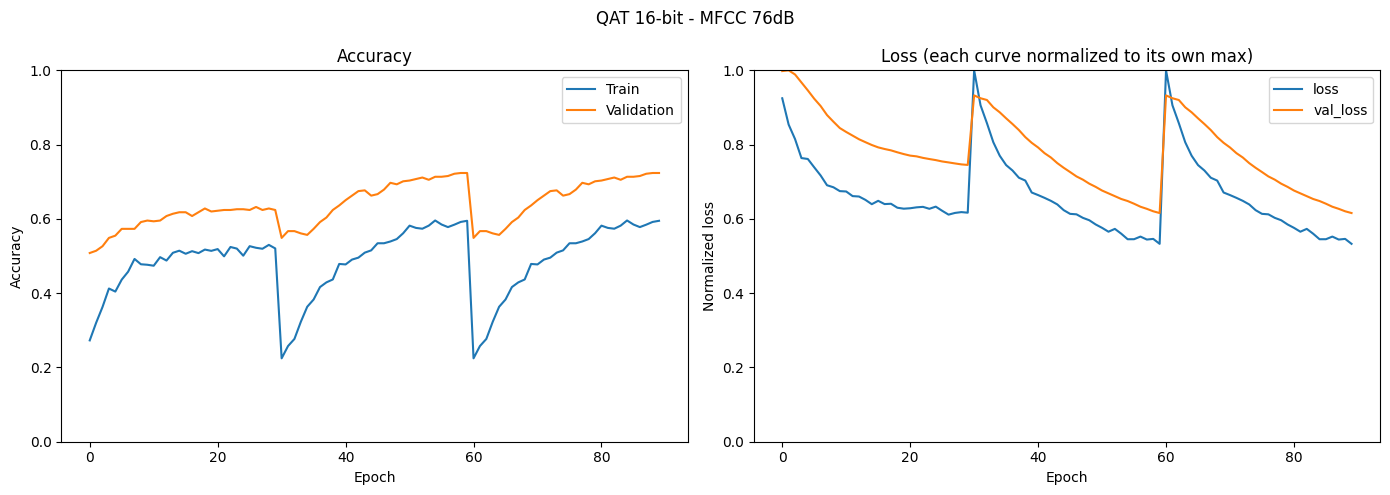


  QAT 8-bit  (integer_bits=4)
Building QAT model and transferring float weights ...
  Transferred weights for 8 layer(s).
Epoch 1/40
72/72 [==============================] - 4s 33ms/step - loss: 1.9640 - accuracy: 0.2733 - val_loss: 1.4280 - val_accuracy: 0.5630
Epoch 2/40
72/72 [==============================] - 2s 27ms/step - loss: 1.5472 - accuracy: 0.4447 - val_loss: 1.3525 - val_accuracy: 0.5142
Epoch 3/40
72/72 [==============================] - 2s 26ms/step - loss: 1.4053 - accuracy: 0.4970 - val_loss: 1.1581 - val_accuracy: 0.6341
Epoch 4/40
72/72 [==============================] - 2s 27ms/step - loss: 1.3236 - accuracy: 0.5352 - val_loss: 1.3380 - val_accuracy: 0.4837
Epoch 5/40
72/72 [==============================] - 2s 27ms/step - loss: 1.2441 - accuracy: 0.5648 - val_loss: 1.0174 - val_accuracy: 0.6911
Epoch 6/40
72/72 [==============================] - 2s 27ms/step - loss: 1.1868 - accuracy: 0.5796 - val_loss: 1.3007 - val_accuracy: 0.5264
Epoch 7/40
72/72 [=============

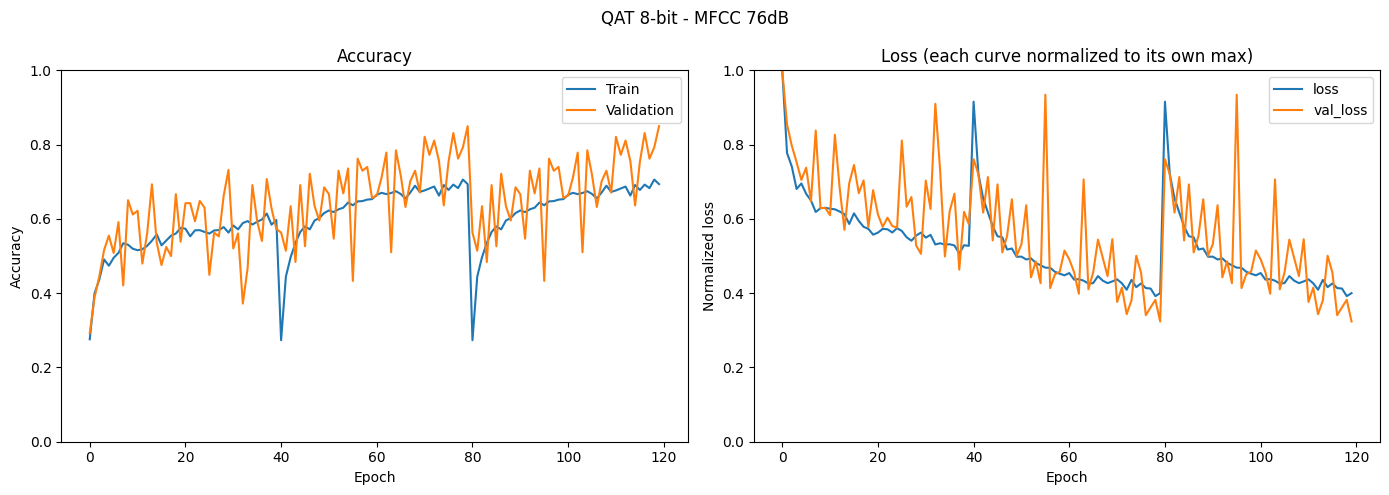


  QAT 4-bit  (integer_bits=2)
Building QAT model and transferring float weights ...
  Transferred weights for 8 layer(s).
Epoch 1/120
72/72 [==============================] - 4s 33ms/step - loss: 2.8741 - accuracy: 0.1628 - val_loss: 6.5186 - val_accuracy: 0.1423
Epoch 2/120
72/72 [==============================] - 2s 27ms/step - loss: 2.5280 - accuracy: 0.1688 - val_loss: 3.5492 - val_accuracy: 0.1423
Epoch 3/120
72/72 [==============================] - 2s 26ms/step - loss: 2.2423 - accuracy: 0.1906 - val_loss: 2.4159 - val_accuracy: 0.1646
Epoch 4/120
72/72 [==============================] - 2s 26ms/step - loss: 2.2147 - accuracy: 0.1797 - val_loss: 2.2466 - val_accuracy: 0.1809
Epoch 5/120
72/72 [==============================] - 2s 26ms/step - loss: 2.1746 - accuracy: 0.1784 - val_loss: 2.2052 - val_accuracy: 0.1809
Epoch 6/120
72/72 [==============================] - 2s 27ms/step - loss: 2.1890 - accuracy: 0.1671 - val_loss: 2.2112 - val_accuracy: 0.1890
Epoch 7/120
72/72 [======

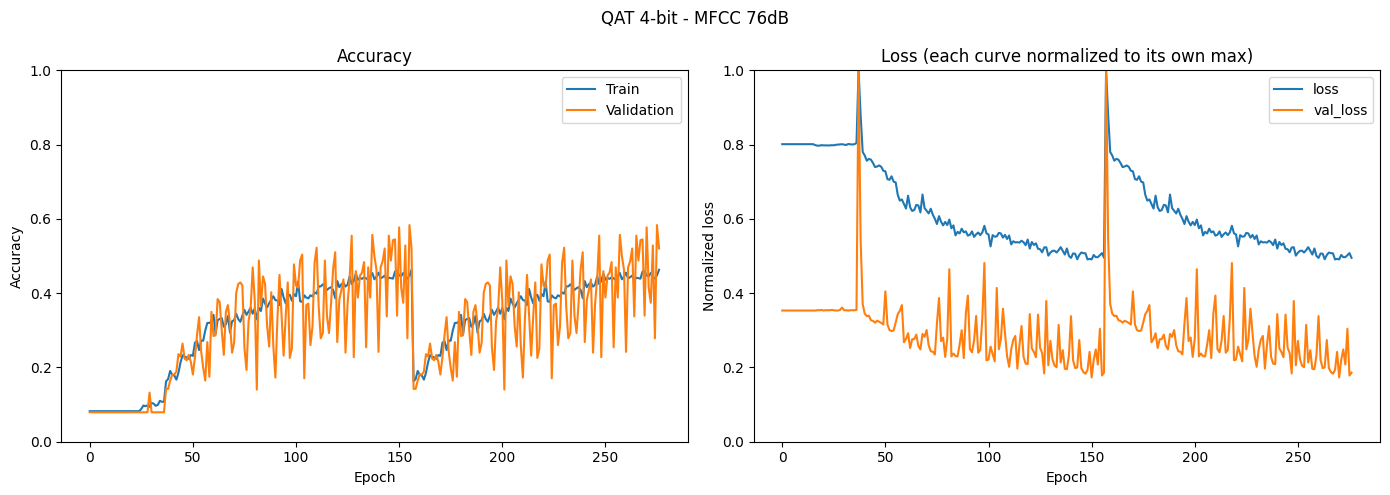

In [9]:

# QAT configs: (total_bits, integer_bits, fine_tune_epochs, learning_rate)
QAT_CONFIGS = [
    (16, 6, 30, 1e-5), # 16-bit: fine-tuning suave desde float
    ( 8, 4, 40, 1e-4), # 8-bit:  paso min ~0.0625, LR 1e-4 → ~62 épocas/step
    ( 4, 2, 120, 5e-4), # 4-bit:  paso min ~0.25,   LR 5e-4 → ~50 épocas/step
]

qat_models   = {}  # bits -> trained QKeras model
qat_results  = {}  # bits -> (loss, accuracy)

for bits, int_bits, ft_epochs, ft_lr in QAT_CONFIGS:
    label     = f'{bits}bit'
    ckpt_dir  = f'./ckpt_MFCC_QAT_{label}_{TARGET_SNR}'
    #best_path = f'{ckpt_dir}/MFCC_QAT_{label}_best.keras'
    best_path = f'{ckpt_dir}/MFCC_QAT_{label}_best.h5'
    hist_path = f'{ckpt_dir}/MFCC_QAT_{label}_history.json'
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f'  QAT {bits}-bit  (integer_bits={int_bits})')
    print(f"{'='*60}")

    if os.path.exists(best_path):
        print(f'  Pre-trained QAT model found: {best_path}')
        print('  Loading.  Delete this file to retrain.')
        model_q = tf.keras.models.load_model(
            best_path, custom_objects=QKERAS_CUSTOM_OBJECTS)
        
        # FIX #7: always recompile with explicit parameters
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print(f"Building QAT model and transferring float weights ...")
        
        model_q = build_qat_model(MFCC_input_shape, NUM_CLASSES, bits, int_bits)
        model_q.summary()

        verify_layer_sizes(model_q)

        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        transfer_float_weights(model_MFCC, model_q)

        # FIX #3: fresh callbacks per training session
        cbs = [
            tf.keras.callbacks.ModelCheckpoint(
                filepath=best_path, monitor='val_accuracy',
                save_best_only=True, verbose=1
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=max(PATIENCE),
                restore_best_weights=True, verbose=1
            ),
        ]

        hist_q = model_q.fit(
            MFCC_dataset_train_batches,
            epochs=ft_epochs,
            validation_data=MFCC_dataset_validation_batches,
            callbacks=[early_stopping_callback]
        )

        # Save best model manually in H5 format (without passing 'options')
        model_q.save(ckpt_dir, save_format='h5')
        print(f'Model saved → {ckpt_dir}')
        save_history(hist_q, hist_path)

    if os.path.exists(hist_path):
        plot_training_history(load_history(hist_path),
                              title=f'QAT {bits}-bit - MFCC {TARGET_SNR}')

    qat_models[bits] = model_q

## Evaluate All Models

In [13]:
all_results = []


#loss, acc = evaluate_model(model_float, ds_test, unique_labels, title='Float 32-bit')
test_loss, test_accuracy = model_MFCC.evaluate(MFCC_dataset_validation_batches)
all_results.append({'model': 'Float 32-bit', 'accuracy': test_accuracy, 'loss': test_loss})

#Might need to load X,Y parameters from Numpy for this
for bits in [16, 8, 4]:
    print(f'\n--- QAT {bits}-bit ---')
    test_loss, test_accuracy  = qat_models[bits].evaluate(MFCC_dataset_validation_batches,verbose=0)
    all_results.append({'model': f'QAT {bits}-bit', 'accuracy': test_accuracy, 'loss': test_loss})

print('\n' + '='*52)
print(f'{"Model":<20} {"Accuracy":>12} {"Loss":>10}')
print('='*52)
for r in all_results:
    print(f"{r['model']:<20} {r['accuracy']:>12.4f} {r['loss']:>10.4f}")
print('='*52)

16/16 [==============================] - 0s 6ms/step - loss: 0.3865 - accuracy: 0.8963

--- QAT 16-bit ---

--- QAT 8-bit ---

--- QAT 4-bit ---

Model                    Accuracy       Loss
Float 32-bit               0.8963     0.3865
QAT 16-bit                 0.7236     0.9609
QAT 8-bit                  0.8496     0.6078
QAT 4-bit                  0.5203     1.2117


## hls4ml Synthesis – Vitis HLS → Bitstream-Ready IP

Each of the four models is converted to a Vitis HLS project and
synthesized for **`xck26-sfvc784-2LV-c`** at **200 MHz (5 ns)**.

The exported IP-XACT package can be added to a Vivado block design
to generate the final bitstream.


In [15]:
def get_hls_config(keras_model, is_qat, bits=32):
    config = hls4ml.utils.config_from_keras_model(
        keras_model, granularity='name'
    )
    config['Model']['Strategy']    = 'Resource'  # minimize LUT / DSP
    config['Model']['ReuseFactor'] = 1

    layer_rf = {
        'conv1':  1,    # 144 MACs / 1 = 144 DSPs
        'conv2':  4,    # 576 MACs / 4 = 144 DSPs
        'conv3':  4,    # 576 MACs / 4 = 144 DSPs
        'dense1': 1,    # 256 MACs / 1 = 256 DSPs
        'output': 1,    # 160 MACs / 1 = 160 DSPs
    }

    for lname, rf in layer_rf.items():
        if lname in config.get('LayerName', {}):
            config['LayerName'][lname]['ReuseFactor'] = rf
            config['LayerName'][lname]['Strategy']    = 'Latency'
    return config

    #if not is_qat:
    #    # Float model: use ap_fixed<32,12> for highest baseline accuracy
    #    config['Model']['Precision'] = 'ap_fixed<32,12>'
    # For QAT models hls4ml reads precision from QKeras quantizers automatically

    # The Flatten -> Dense(128) layer has 22 400 inputs.
    # xck26 has ~128 DSP48s. Minimum RF = ceil(22400/128) = 175.
    # Using 256 (next power-of-two) for alignment.
    #LARGE_RF = 256
    #for lname in config['LayerName']:
    #    if 'dense1' in lname:
    #        config['LayerName'][lname]['ReuseFactor'] = LARGE_RF
    #        config['LayerName'][lname]['Strategy']    = 'Resource'
    #return config


def synthesize_model(keras_model, output_dir, label, is_qat=False, bits=32):
    print(f"\n{'--'*30}")
    print(f'  Synthesizing : {label}')
    print(f'  Output dir   : {output_dir}')
    print(f"{'--'*30}")

    config    = get_hls_config(keras_model, is_qat=is_qat, bits=bits)
    hls_model = hls4ml.converters.convert_from_keras_model(
        keras_model,
        hls_config   = config,
        output_dir   = output_dir,
        backend      = 'Vitis',
        part         = FPGA_PART,
        clock_period = CLOCK_PERIOD,   # 5 ns -> 200 MHz
        io_type      = 'io_stream',   # MANDATORY for CNNs
    )

    # C simulation checks functional correctness before RTL synthesis
    hls_model.compile()

    # Full synthesis + IP-XACT export (Vivado-importable bitstream-ready IP)
    hls_model.build(csim=False, synth=True, cosim=False, export=True)

    print(f'  Done: {label}')
    return hls_model


def parse_synth_report(output_dir, label):
    rpt = {'model': label}
    candidates = [
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'myproject_csynth.rpt'),
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'csynth.rpt'),
    ]
    rpt_path = next((p for p in candidates if os.path.exists(p)), None)
    if rpt_path is None:
        print(f'  Warning: report not found for {label}')
        return rpt
    content = open(rpt_path).read()

    #Timing
    m = re.search(
        r'\|ap_clk\s*\|\s*([\d.]+)\s*ns\s*\|\s*([\d.]+)\s*ns\s*\|\s*([\d.]+)\s*ns\s*\|',
        content
    )
    if m:
        target_ns, estimate_ns = float(m.group(1)), float(m.group(2))
        rpt['clk_target_ns']   = target_ns
        rpt['clk_estimate_ns'] = estimate_ns
        rpt['fmax_mhz']        = round(1000.0 / estimate_ns, 1)
        rpt['timing_met']      = estimate_ns < target_ns

    # Latency
    lat_start    = content.find('+ Latency:')
    detail_start = content.find('+ Detail:', lat_start)
    if lat_start >= 0:
        lat_region = content[lat_start : detail_start] if detail_start > lat_start \
                     else content[lat_start : lat_start + 1500]
        m = re.search(
            r'\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*([\d.]+)\s*us\s*\|\s*([\d.]+)\s*us\s*\|',
            lat_region
        )
        if m:
            rpt['lat_min_cyc'] = int(m.group(1))
            rpt['lat_max_cyc'] = int(m.group(2))
            rpt['lat_min_us']  = round(float(m.group(3)), 3)
            rpt['lat_max_us']  = round(float(m.group(4)), 3)

    # Resources estimates
    def _util_row(keyword):
        pat = rf'\|{keyword}\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|\s*([\d-]+)\s*\|'
        m = re.search(pat, content, re.IGNORECASE)
        if m:
            return [int(x) if x.strip() != '-' else None for x in m.groups()]
        return None

    _COL = ['BRAM_18K', 'DSP', 'FF', 'LUT']
    tot = _util_row('Total')
    avl = _util_row('Available')
    pct = _util_row(r'Utilization \(%\)')
    for i, res in enumerate(_COL):
        if tot and tot[i] is not None: rpt[f'{res}_used']  = tot[i]
        if avl and avl[i] is not None: rpt[f'{res}_avail'] = avl[i]
        if pct and pct[i] is not None: rpt[f'{res}_pct']   = pct[i]
    return rpt


# --- Test -----------------------------------
_test_dir = os.path.join(HLS_BASE_DIR, 'float_32')
_test_rpt  = os.path.join(_test_dir, 'myproject_prj', 'solution1',
                           'syn', 'report', 'myproject_csynth.rpt')
if os.path.exists(_test_rpt):
    _r = parse_synth_report(_test_dir, 'Float 32-bit (test)')
    print('Latencia: min={lat_min_us} us, max={lat_max_us} us'.format(**_r))
    print('Fmax:     {fmax_mhz} MHz  (estimado {clk_estimate_ns} ns)'.format(**_r))
    print('Timing met:', _r.get('timing_met'))
    print('BRAM_18K: {BRAM_18K_used}/{BRAM_18K_avail} ({BRAM_18K_pct}%)'.format(**_r))
    print('DSP:      {DSP_used}/{DSP_avail} ({DSP_pct}%)'.format(**_r))
else:
    print('Funciones definidas. Ejecutar sintesis para obtener reportes.')

Funciones definidas. Ejecutar sintesis para obtener reportes.


## Preview Settings before synthesis

In [19]:
config_preview = get_hls_config(model_MFCC,False)

print('hls4ml configuration for compact model:')
print(f"  Global Strategy: {config_preview['Model']['Strategy']}")
print(f"  io_type        : io_stream")
print('  ReuseFactor per layer:')
for lname, lcfg in config_preview.get('LayerName', {}).items():
    rf = lcfg.get('ReuseFactor', '—')
    st = lcfg.get('Strategy', '—')
    if rf != '—' or st != '—':
        print(f'    {lname:20s}: RF={rf}, Strategy={st}')

print('\nConverting model (without synthesis)...')
hls_model_preview = hls4ml.converters.convert_from_keras_model(
    model_MFCC,
    hls_config   = config_preview,
    output_dir   = './hls4ml_preview_compact',
    backend      = 'Vitis',
    part         = FPGA_PART,
    clock_period = CLOCK_PERIOD,
    io_type      = 'io_stream',
)

print('\nLayer sizes:')
verify_layer_sizes(model_MFCC)

try:
    hls4ml.utils.plot_model(
        hls_model_preview, show_shapes=True,
        show_precision=True, to_file=None
    )
except Exception as e:
    print(f'plot_model not available: {e}')

hls4ml configuration for compact model:
  Global Strategy: Resource
  io_type        : io_stream
  ReuseFactor per layer:
    conv1               : RF=1, Strategy=Latency
    conv2               : RF=4, Strategy=Latency
    conv3               : RF=4, Strategy=Latency
    dense1              : RF=1, Strategy=Latency
    output              : RF=1, Strategy=Latency

Converting model (without synthesis)...

Layer sizes:

Verifying layer sizes (limit: 4096)
--------------------------------------------------------------------
  OK         conv1               :     144 elements | shape (3, 3, 2, 8)
  OK         bn1                 :       8 elements | shape (8,)
  OK         conv2               :     576 elements | shape (3, 3, 8, 8)
  OK         bn2                 :       8 elements | shape (8,)
  OK         conv3               :     576 elements | shape (3, 3, 8, 8)
  OK         bn3                 :       8 elements | shape (8,)
  OK         dense1              :    1024 elements | shap

## Run Synthesis

In [20]:
os.makedirs(HLS_BASE_DIR, exist_ok=True)

synth_targets = [
    # (model,           subdir,      label,         is_qat, bits)
    (model_MFCC,       'float_32',  'Float 32-bit', False, 32),
    (qat_models[16],    'qat_16bit', 'QAT 16-bit',   True,  16),
    (qat_models[8],     'qat_8bit',  'QAT 8-bit',    True,   8),
    (qat_models[4],     'qat_4bit',  'QAT 4-bit',    True,   4),
]

hls_handles   = {}
synth_reports = []

for model, subdir, label, is_qat, bits in synth_targets:
    out_dir = os.path.join(HLS_BASE_DIR, subdir)
    hm = synthesize_model(model, out_dir, label, is_qat=is_qat, bits=bits)
    hls_handles[label]   = hm
    synth_reports.append(parse_synth_report(out_dir, label))


------------------------------------------------------------
  Synthesizing : Float 32-bit
  Output dir   : ./hls4ml_output/float_32
------------------------------------------------------------

****** vitis-run v2024.1 (64-bit)
  **** SW Build 5074859 on 2024-05-20-23:21:20
  **** Start of session at: Sun Mar 22 14:31:48 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/barnesrob/Documents/VSProj/CNN_HLS4ML/hls4ml_output/float_32/build_prj.tcl -work_dir /home/barnesrob/Documents/VSProj/CNN_HLS4ML/hls4ml_output/float_32

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Sun Mar 22 14:31:49 2026
    **

## Results Summary

In [23]:
# ── Accuracy / loss ──────────────────────────────────────────────────────
print('='*55)
print(f'{"Model":<18} {"Accuracy":>10} {"Loss":>10}')
print('='*55)
for r in all_results:
    print(f"{r['model']:<18} {r['accuracy']:>10.4f} {r['loss']:>10.4f}")
print('='*55)

# ── Synthesis resources & latency ────────────────────────────────────────
print('\n')
df_rpt = pd.DataFrame(synth_reports)
want   = ['model',
          'lat_min_us', 'lat_max_us',
          'LUT_used', 'LUT_pct',
          'FF_used',  'FF_pct',
          'DSP_used', 'DSP_pct',
          'BRAM_18K_used', 'BRAM_18K_pct']
show   = [c for c in want if c in df_rpt.columns]
print('\nSynthesis results:')
print(df_rpt[show].to_string(index=False))
print(f'\nTarget: {FPGA_PART} @ {1000 // CLOCK_PERIOD} MHz')
print('IP-XACT packages: <output_dir>/myproject_prj/solution1/impl/ip/')

print('Import them into a Vivado block design and run Generate Bitstream.')

Model                Accuracy       Loss
Float 32-bit           0.8963     0.3865
QAT 16-bit             0.7236     0.9609
QAT 8-bit              0.8496     0.6078
QAT 4-bit              0.5203     1.2117



Synthesis results:
       model  lat_min_us  lat_max_us  LUT_used  LUT_pct  FF_used  FF_pct  DSP_used  DSP_pct  BRAM_18K_used  BRAM_18K_pct
Float 32-bit      95.960      95.960    188111      160    61589      26      1669      133            510           177
  QAT 16-bit      95.955      95.955    126052      107    50222      21      1187       95            516           179
   QAT 8-bit      64.720      64.720     75462       64    22732       9        32        2            379           131
   QAT 4-bit      64.725      64.725     35517       30    14941       6        34        2            310           107

Target: xck26-sfvc784-2LV-c @ 200 MHz
IP-XACT packages: <output_dir>/myproject_prj/solution1/impl/ip/
Import them into a Vivado block design and run Generate Bitstream